# STEP 4.1.3: SARIMA/SARIMAX

Mục tiêu: xây dựng mô hình SARIMA/SARIMAX để dự báo `cpi_mom`.

Nội dung:
- Kiểm tra tính dừng và mùa vụ.
- Biến đổi biến ngoại sinh.
- Chọn biến ngoại sinh bằng tương quan trễ.
- Tối ưu tham số SARIMA/SARIMAX.
- Đánh giá mô hình trên tập test.
- Kiểm định phần dư.
- Chỉ vẽ dự báo tương lai nếu mô hình đạt benchmark.

## 1. Thiết lập

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import jarque_bera
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

DATA_DIR = os.path.join(os.getcwd(), "data", "processed")
OUTPUT_DIR = os.path.join(os.getcwd(), "outputs", "step4_sarimax")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Data:", DATA_DIR)
print("Output:", OUTPUT_DIR)

Data: d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\data\processed
Output: d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\outputs\step4_sarimax


## 2. Load dữ liệu

In [2]:
cleaned_data = pd.read_csv(os.path.join(DATA_DIR, "cpi_02_06_selected_variables.csv"))
cleaned_data["date"] = pd.to_datetime(cleaned_data["date"])
cleaned_data = cleaned_data.sort_values("date").reset_index(drop=True)

print("Số dòng, số cột:", cleaned_data.shape)
print("Thời gian:", cleaned_data["date"].min().date(), "đến", cleaned_data["date"].max().date())
print("Missing:", cleaned_data.isnull().sum().sum())

Số dòng, số cột: (360, 13)
Thời gian: 1995-01-01 đến 2024-12-01
Missing: 0


## 3. Chọn biến mục tiêu và biến ngoại sinh

In [3]:
target_var = "cpi_mom"

candidate_exog_vars = [
    'cpi_mom', 'broad_money', 'ppi_qoq', 'wti', 'gold', 'policy_rate', 'VNINDEX', 'NIKKEI225', 'USDVND'
]

candidate_exog_vars = [v for v in candidate_exog_vars if v in cleaned_data.columns]

if target_var not in cleaned_data.columns:
    raise ValueError(f"Không tìm thấy biến mục tiêu: {target_var}")

df = cleaned_data[["date", target_var] + candidate_exog_vars].copy()
df = df.dropna().sort_values("date").set_index("date")
df = df.asfreq("MS").ffill().bfill()

print("Target:", target_var)
print("Số biến ngoại sinh:", len(candidate_exog_vars))
print("Shape:", df.shape)

Target: cpi_mom
Số biến ngoại sinh: 9
Shape: (360, 10)


## 4. Kiểm định tính dừng của target

In [4]:
def adf_pvalue(series):
    try:
        s = pd.Series(series).dropna()
        if len(s) < 4:
            return np.nan
        result = adfuller(s, autolag="AIC", regression="c")
        return result[1]
    except Exception as e:
        print(f"ADF error: {e}")
        return np.nan


def kpss_pvalue(series):
    try:
        s = pd.Series(series).dropna()
        if len(s) < 4:
            return np.nan
        result = kpss(s, regression="c", nlags="auto")
        return result[1]
    except Exception as e:
        print(f"KPSS error: {e}")
        return np.nan


y = df[target_var].astype(float)
if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]
y = y.squeeze()
print("Target series info:")
print(f"  Length: {len(y)}, Non-null: {y.notna().sum()}")
print(f"  Sample values:\n{y.head()}")

adf_p = adf_pvalue(y)
kpss_p = kpss_pvalue(y)

suggested_d = 0 if (adf_p is not None and adf_p < 0.05 and kpss_p is not None and kpss_p > 0.05) else 1

print("ADF p-value:", round(adf_p, 6) if adf_p is not None else "N/A")
print("KPSS p-value:", round(kpss_p, 6) if kpss_p is not None else "N/A")
print("d đề xuất:", suggested_d)

Target series info:
  Length: 360, Non-null: 360
  Sample values:
date
1995-01-01    103.8
1995-02-01    103.4
1995-03-01    100.2
1995-04-01    101.0
1995-05-01    101.8
Freq: MS, Name: cpi_mom, dtype: float64
ADF p-value: 0.003148
KPSS p-value: 0.1
d đề xuất: 0


C:\Users\HP\AppData\Local\Temp\ipykernel_18252\2256461423.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(s, regression="c", nlags="auto")


## 5. Phân tích mùa vụ

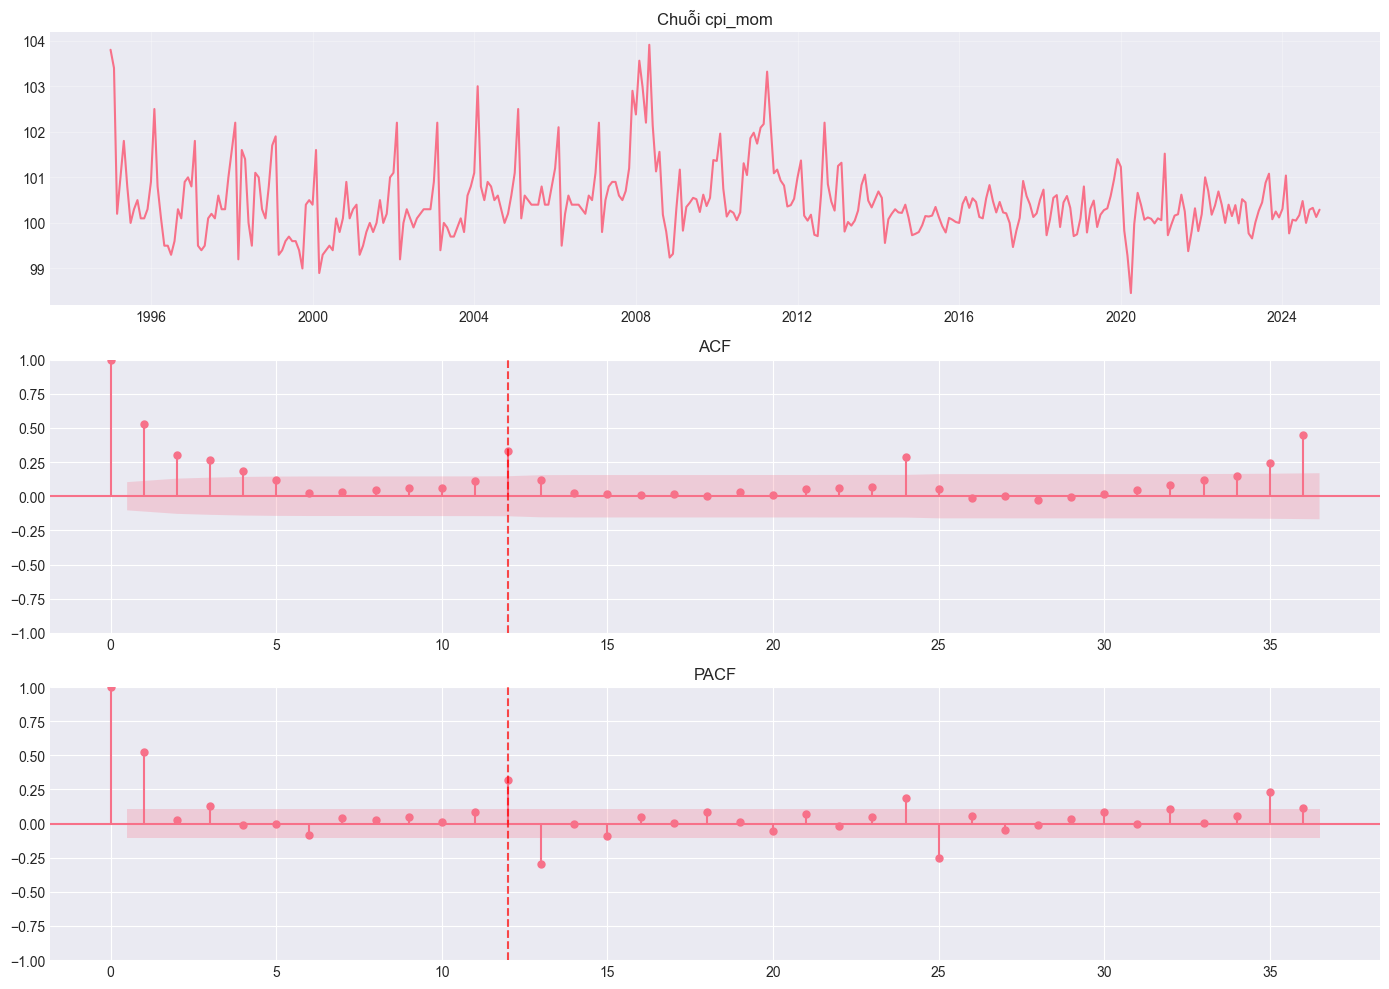

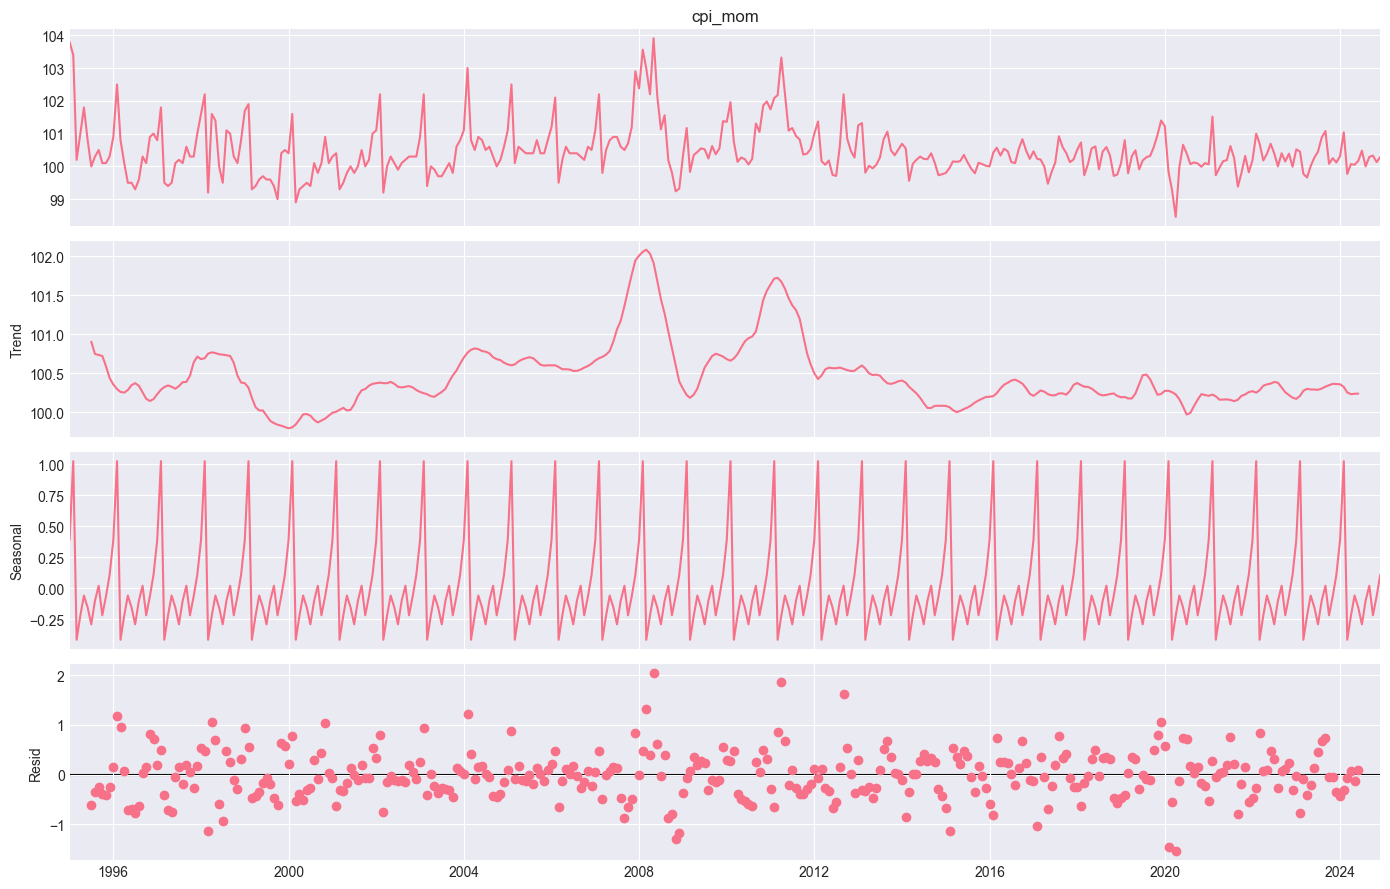

Trend strength: 0.414
Seasonal strength: 0.3601


In [5]:
seasonal_period = 12

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(y.index, y.values)
axes[0].set_title(f"Chuỗi {target_var}")
axes[0].grid(True, alpha=0.3)

plot_acf(y, lags=min(36, len(y)//2), ax=axes[1])
axes[1].axvline(seasonal_period, color="red", linestyle="--", alpha=0.7)
axes[1].set_title("ACF")

plot_pacf(y, lags=min(36, len(y)//2 - 1), ax=axes[2], method="ywm")
axes[2].axvline(seasonal_period, color="red", linestyle="--", alpha=0.7)
axes[2].set_title("PACF")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "target_acf_pacf.png"), dpi=150)
plt.show()

try:
    dec = seasonal_decompose(y, model="additive", period=seasonal_period)
    fig = dec.plot()
    fig.set_size_inches(14, 9)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "seasonal_decompose.png"), dpi=150)
    plt.show()

    trend_strength = dec.trend.var() / (dec.trend.var() + dec.resid.var())
    seasonal_strength = dec.seasonal.var() / (dec.seasonal.var() + dec.resid.var())
    print("Trend strength:", round(trend_strength, 4))
    print("Seasonal strength:", round(seasonal_strength, 4))
except Exception as e:
    seasonal_strength = 0
    print("Không phân rã mùa vụ được:", e)

## 6. Biến đổi biến ngoại sinh

In [6]:
def classify_stationarity(series):
    a = adf_pvalue(series)
    k = kpss_pvalue(series)
    if pd.notna(a) and pd.notna(k) and a < 0.05 and k > 0.05:
        return "I(0)", a, k
    if pd.notna(a) and a > 0.05:
        return "Non-stationary", a, k
    return "Mixed", a, k


df_model = pd.DataFrame(index=df.index)
target_series = df[target_var].astype(float)
if isinstance(target_series, pd.DataFrame):
    target_series = target_series.iloc[:, 0]
df_model[target_var] = target_series.squeeze()

rows = []
exog_transformed_cols = []

for col in candidate_exog_vars:
    s = df[col].astype(float)
    if isinstance(s, pd.DataFrame):
        s = s.iloc[:, 0]
    s = s.squeeze()

    if col.startswith("shock_") or col in ["month", "quarter"]:
        new_col = col
        df_model[new_col] = s
        method = "level"
        status, a0, k0, a1, k1 = "calendar/dummy", np.nan, np.nan, np.nan, np.nan
    else:
        status, a0, k0 = classify_stationarity(s)
        if status == "I(0)":
            new_col = col
            df_model[new_col] = s
            method = "level"
            a1, k1 = a0, k0
        else:
            if (s > 0).all():
                new_col = f"dlog_{col}"
                df_model[new_col] = np.log(s).diff()
                method = "log_diff"
            else:
                new_col = f"diff_{col}"
                df_model[new_col] = s.diff()
                method = "diff"
            a1, k1 = adf_pvalue(df_model[new_col]), kpss_pvalue(df_model[new_col])

    exog_transformed_cols.append(new_col)
    rows.append({"gốc": col, "biến_đổi": new_col, "cách_làm": method, "trạng_thái": status, "ADF_sau": a1, "KPSS_sau": k1})

transform_df = pd.DataFrame(rows)
df_model = df_model.dropna()

print(transform_df.to_string(index=False))
print("Shape sau biến đổi:", df_model.shape)

        gốc         biến_đổi cách_làm     trạng_thái      ADF_sau  KPSS_sau
    cpi_mom          cpi_mom    level           I(0) 3.147732e-03       0.1
broad_money dlog_broad_money log_diff Non-stationary 2.078913e-04       0.1
    ppi_qoq     diff_ppi_qoq     diff Non-stationary 1.350403e-14       0.1
        wti         dlog_wti log_diff Non-stationary 1.462145e-18       0.1
       gold        dlog_gold log_diff Non-stationary 0.000000e+00       0.1
policy_rate dlog_policy_rate log_diff Non-stationary 1.100161e-12       0.1
    VNINDEX     dlog_VNINDEX log_diff Non-stationary 2.676718e-12       0.1
  NIKKEI225   dlog_NIKKEI225 log_diff Non-stationary 5.167798e-30       0.1
     USDVND      dlog_USDVND log_diff Non-stationary 1.861147e-03       0.1
Shape sau biến đổi: (359, 9)


C:\Users\HP\AppData\Local\Temp\ipykernel_18252\2256461423.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(s, regression="c", nlags="auto")
C:\Users\HP\AppData\Local\Temp\ipykernel_18252\2256461423.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(s, regression="c", nlags="auto")
C:\Users\HP\AppData\Local\Temp\ipykernel_18252\2256461423.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(s, regression="c", nlags="auto")
C:\Users\HP\AppData\Local\Temp\ipykernel_18252\2256461423.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in th

## 7. Chọn biến ngoại sinh

In [7]:
# Lấy các biến ngoại sinh đã biến đổi (loại target_var)
exog_vars = [col for col in exog_transformed_cols if col != target_var]

print("Biến ngoại sinh được sử dụng:")
print(exog_vars)

# Tạo exog_sets đơn giản
exog_sets = {
    "SARIMA": [],
    "SARIMAX": exog_vars
}

for name, cols in exog_sets.items():
    print(f"{name}: {len(cols)} biến")

Biến ngoại sinh được sử dụng:
['dlog_broad_money', 'diff_ppi_qoq', 'dlog_wti', 'dlog_gold', 'dlog_policy_rate', 'dlog_VNINDEX', 'dlog_NIKKEI225', 'dlog_USDVND']
SARIMA: 0 biến
SARIMAX: 8 biến


Biến ngoại sinh được lựa chọn từ các biến đã biến đổi để đảm bảo tính dừng. Mô hình so sánh hai cách tiếp cận: SARIMA (không sử dụng biến ngoại sinh) và SARIMAX (sử dụng tất cả biến ngoại sinh đã biến đổi).

## 8. Chia train/test

In [8]:
test_ratio = 0.2
train_size = int(len(df_model) * (1 - test_ratio))

y_all = df_model[target_var]
y_train = y_all.iloc[:train_size]
y_test = y_all.iloc[train_size:]

print("Train:", len(y_train), y_train.index.min().date(), "đến", y_train.index.max().date())
print("Test:", len(y_test), y_test.index.min().date(), "đến", y_test.index.max().date())

Train: 287 1995-02-01 đến 2018-12-01
Test: 72 2019-01-01 đến 2024-12-01


## 9. Tối ưu SARIMA/SARIMAX

In [9]:
p_values = [0, 1]
d_values = [suggested_d]
q_values = [0, 1]

P_values = [0, 1]
D_values = [0]
Q_values = [0, 1]
s = 12

# Nếu mùa vụ rất yếu, vẫn cho seasonal_order với D=0 để kiểm tra thành phần AR/MA mùa vụ.


def fit_model(y_train, exog_train, order, seasonal_order):
    try:
        model = SARIMAX(
            y_train,
            exog=exog_train,
            order=order,
            seasonal_order=seasonal_order,
            trend="c",
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        res = model.fit(disp=False, maxiter=300)
        if not res.mle_retvals.get("converged", False):
            return None
        return res
    except Exception:
        return None


results = []
fitted_models = {}

for exog_name, exog_cols in exog_sets.items():
    exog_train = None if len(exog_cols) == 0 else df_model[exog_cols].iloc[:train_size]

    for p in p_values:
        for d in d_values:
            for q in q_values:
                for P in P_values:
                    for D in D_values:
                        for Q in Q_values:
                            order = (p, d, q)
                            seasonal_order = (P, D, Q, s)
                            res = fit_model(y_train, exog_train, order, seasonal_order)
                            if res is None:
                                continue
                            key = f"{exog_name}_{order}_{seasonal_order}"
                            fitted_models[key] = res
                            results.append({
                                "exog_set": exog_name,
                                "exog_cols": exog_cols,
                                "order": order,
                                "seasonal_order": seasonal_order,
                                "AIC": res.aic,
                                "BIC": res.bic,
                                "key": key
                            })

grid_results_df = pd.DataFrame(results)
print("Số mô hình hội tụ:", len(grid_results_df))
print(grid_results_df.sort_values("AIC").head(10).to_string(index=False))

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization fail

Số mô hình hội tụ: 18
exog_set                                                                                                          exog_cols     order seasonal_order        AIC        BIC                             key
  SARIMA                                                                                                                 [] (0, 0, 1)  (1, 0, 1, 12) 474.460337 492.507696  SARIMA_(0, 0, 1)_(1, 0, 1, 12)
  SARIMA                                                                                                                 [] (1, 0, 1)  (1, 0, 1, 12) 505.912832 527.569663  SARIMA_(1, 0, 1)_(1, 0, 1, 12)
  SARIMA                                                                                                                 [] (1, 0, 1)  (1, 0, 0, 12) 506.229519 524.295159  SARIMA_(1, 0, 1)_(1, 0, 0, 12)
  SARIMA                                                                                                                 [] (1, 0, 0)  (0, 0, 1, 12) 524.979515 539.43

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 10. Đánh giá mô hình

In [10]:
def metrics(actual, pred):
    actual = np.asarray(actual)
    pred = np.asarray(pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    ss_res = np.sum((actual - pred) ** 2)
    ss_tot = np.sum((actual - np.mean(actual)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return rmse, mae, mape, r2


def evaluate_row(row):
    res = fitted_models[row["key"]]
    exog_cols = row["exog_cols"]
    exog_test = None if len(exog_cols) == 0 else df_model[exog_cols].iloc[train_size:]

    pred = res.get_forecast(steps=len(y_test), exog=exog_test)
    mean = pred.predicted_mean
    ci = pred.conf_int(alpha=0.05)

    rmse, mae, mape, r2 = metrics(y_test.values, mean.values)

    rw_pred = np.repeat(y_train.iloc[-1], len(y_test))
    mean_pred = np.repeat(y_train.mean(), len(y_test))
    rmse_rw, _, _, _ = metrics(y_test.values, rw_pred)
    rmse_mean, _, _, _ = metrics(y_test.values, mean_pred)

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R2": r2,
        "RMSE_RW": rmse_rw,
        "Model_vs_RW": rmse / rmse_rw if rmse_rw > 0 else np.nan,
        "RMSE_Mean": rmse_mean,
        "Model_vs_Mean": rmse / rmse_mean if rmse_mean > 0 else np.nan,
        "pred_mean": mean,
        "pred_ci": ci
    }

eval_rows = []
eval_objects = {}

for _, row in grid_results_df.iterrows():
    try:
        out = evaluate_row(row)
        item = row.to_dict()
        item.update({k: v for k, v in out.items() if k not in ["pred_mean", "pred_ci"]})
        eval_rows.append(item)
        eval_objects[row["key"]] = out
    except Exception:
        pass

model_eval_df = pd.DataFrame(eval_rows).sort_values("RMSE")

cols = ["exog_set", "order", "seasonal_order", "AIC", "BIC", "RMSE", "MAE", "MAPE", "R2", "RMSE_RW", "Model_vs_RW", "RMSE_Mean", "Model_vs_Mean", "key"]
print(model_eval_df[cols].head(15).to_string(index=False))

exog_set     order seasonal_order        AIC        BIC     RMSE      MAE     MAPE        R2  RMSE_RW  Model_vs_RW  RMSE_Mean  Model_vs_Mean                             key
  SARIMA (0, 0, 1)  (1, 0, 1, 12) 474.460337 492.507696 0.482143 0.367407 0.366868 -0.054693 0.686673     0.702144   0.536969       0.897897  SARIMA_(0, 0, 1)_(1, 0, 1, 12)
  SARIMA (1, 0, 1)  (1, 0, 1, 12) 505.912832 527.569663 0.512342 0.391813 0.391322 -0.190952 0.686673     0.746123   0.536969       0.954137  SARIMA_(1, 0, 1)_(1, 0, 1, 12)
  SARIMA (1, 0, 1)  (1, 0, 0, 12) 506.229519 524.295159 0.516678 0.394904 0.394412 -0.211195 0.686673     0.752437   0.536969       0.962212  SARIMA_(1, 0, 1)_(1, 0, 0, 12)
 SARIMAX (0, 0, 1)  (0, 0, 0, 12) 610.536738 650.714119 0.518596 0.405402 0.405031 -0.220204 0.686673     0.755230   0.536969       0.965784 SARIMAX_(0, 0, 1)_(0, 0, 0, 12)
  SARIMA (1, 0, 0)  (1, 0, 0, 12) 534.367988 548.820501 0.522433 0.405580 0.405158 -0.238327 0.686673     0.760818   0.536969       0.9

## 11. Mô hình tốt nhất

In [11]:
best_row = model_eval_df.iloc[0]
best_key = best_row["key"]
best_model = fitted_models[best_key]
best_eval = eval_objects[best_key]

print("Mô hình tốt nhất:", best_key)
print("Exog:", best_row["exog_set"])
print("Order:", best_row["order"])
print("Seasonal order:", best_row["seasonal_order"])
print("RMSE:", round(best_row["RMSE"], 6))
print("MAE:", round(best_row["MAE"], 6))
print("R2:", round(best_row["R2"], 4))
print("Model_vs_RW:", round(best_row["Model_vs_RW"], 4))
print(best_model.summary())

Mô hình tốt nhất: SARIMA_(0, 0, 1)_(1, 0, 1, 12)
Exog: SARIMA
Order: (0, 0, 1)
Seasonal order: (1, 0, 1, 12)
RMSE: 0.482143
MAE: 0.367407
R2: -0.0547
Model_vs_RW: 0.7021
                                     SARIMAX Results                                      
Dep. Variable:                            cpi_mom   No. Observations:                  287
Model:             SARIMAX(0, 0, 1)x(1, 0, 1, 12)   Log Likelihood                -232.230
Date:                            Tue, 02 Jun 2026   AIC                            474.460
Time:                                    20:52:49   BIC                            492.508
Sample:                                02-01-1995   HQIC                           481.705
                                     - 12-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------

## 12. Actual vs Forecast

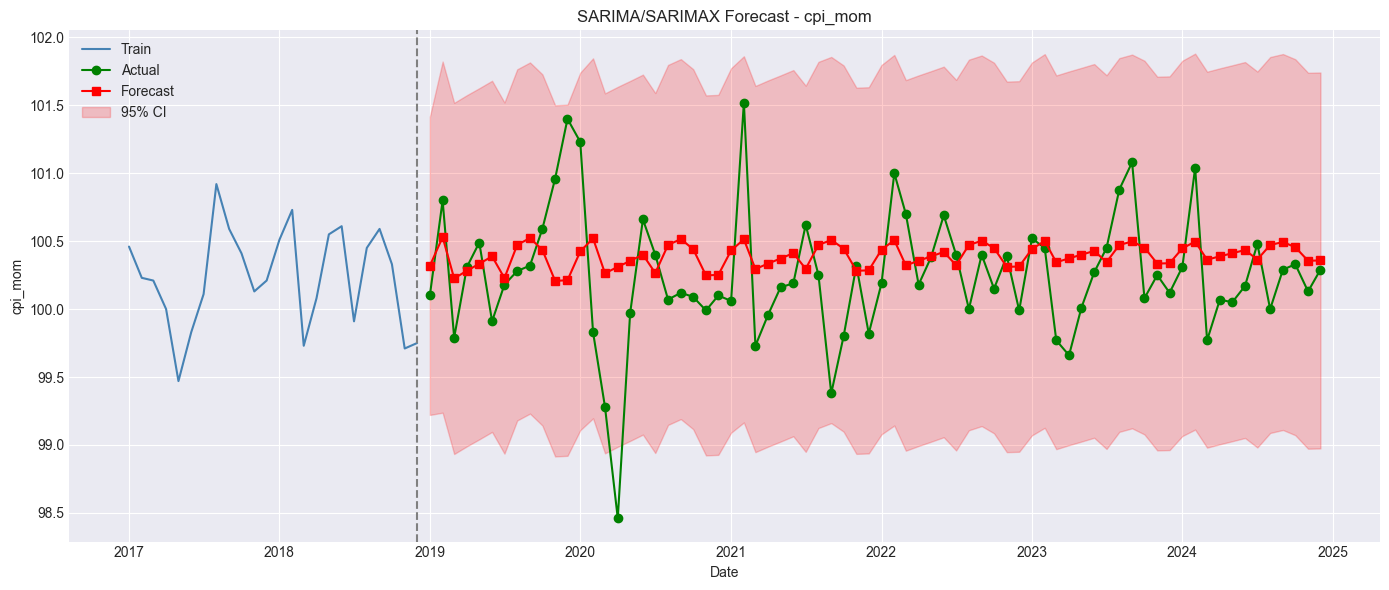

In [12]:
pred_mean = best_eval["pred_mean"]
pred_ci = best_eval["pred_ci"]

plt.figure(figsize=(14, 6))
plt.plot(y_train.index[-24:], y_train.iloc[-24:], label="Train", color="steelblue")
plt.plot(y_test.index, y_test.values, label="Actual", color="green", marker="o")
plt.plot(pred_mean.index, pred_mean.values, label="Forecast", color="red", marker="s")
plt.fill_between(pred_ci.index, pred_ci.iloc[:, 0], pred_ci.iloc[:, 1], color="red", alpha=0.2, label="95% CI")
plt.axvline(y_train.index[-1], color="gray", linestyle="--")
plt.title(f"SARIMA/SARIMAX Forecast - {target_var}")
plt.xlabel("Date")
plt.ylabel(target_var)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# in ra số liệu cpi_mom
print("CPI MoM actual:")
print(y_test.round(4).to_string())
# thực tế
print("\nCPI MoM forecast:")
print(pred_mean.round(4).to_string())

CPI MoM actual:
date
2019-01-01    100.10
2019-02-01    100.80
2019-03-01     99.79
2019-04-01    100.31
2019-05-01    100.49
2019-06-01     99.91
2019-07-01    100.18
2019-08-01    100.28
2019-09-01    100.32
2019-10-01    100.59
2019-11-01    100.96
2019-12-01    101.40
2020-01-01    101.23
2020-02-01     99.83
2020-03-01     99.28
2020-04-01     98.46
2020-05-01     99.97
2020-06-01    100.66
2020-07-01    100.40
2020-08-01    100.07
2020-09-01    100.12
2020-10-01    100.09
2020-11-01     99.99
2020-12-01    100.10
2021-01-01    100.06
2021-02-01    101.52
2021-03-01     99.73
2021-04-01     99.96
2021-05-01    100.16
2021-06-01    100.19
2021-07-01    100.62
2021-08-01    100.25
2021-09-01     99.38
2021-10-01     99.80
2021-11-01    100.32
2021-12-01     99.82
2022-01-01    100.19
2022-02-01    101.00
2022-03-01    100.70
2022-04-01    100.18
2022-05-01    100.38
2022-06-01    100.69
2022-07-01    100.40
2022-08-01    100.00
2022-09-01    100.40
2022-10-01    100.15
2022-11-01   

## 13. Kiểm định phần dư

Ljung-Box:
       lb_stat      lb_pvalue
5   809.851320  8.551746e-173
10  993.791452  4.067063e-207
Jarque-Bera p-value: 0.0
ARCH p-value: 0.0


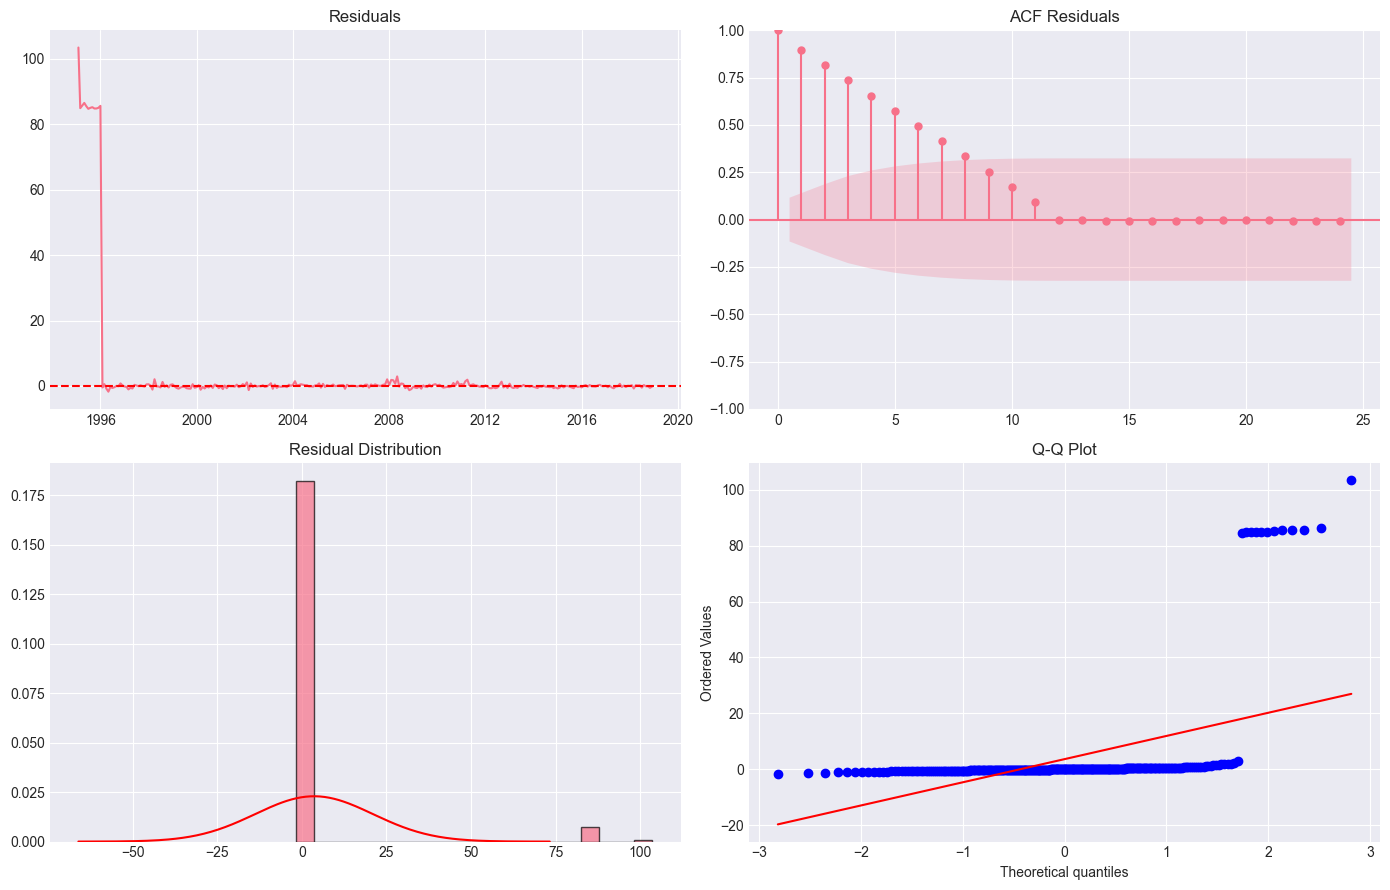

In [14]:
resid = best_model.resid.dropna()

ljung = acorr_ljungbox(resid, lags=[5, 10], return_df=True)
jb_stat, jb_p = jarque_bera(resid)

try:
    arch_stat, arch_p, _, _ = het_arch(resid, nlags=5)
except Exception:
    arch_stat, arch_p = np.nan, np.nan

print("Ljung-Box:")
print(ljung)
print("Jarque-Bera p-value:", round(jb_p, 6))
print("ARCH p-value:", round(arch_p, 6))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(resid.index, resid.values)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("Residuals")

plot_acf(resid, lags=min(24, len(resid)//2), ax=axes[0, 1])
axes[0, 1].set_title("ACF Residuals")

axes[1, 0].hist(resid.values, bins=20, density=True, alpha=0.7, edgecolor="black")
mu, sigma = np.mean(resid), np.std(resid)
if sigma > 0:
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
    axes[1, 0].plot(x, stats.norm.pdf(x, mu, sigma), color="red")
axes[1, 0].set_title("Residual Distribution")

stats.probplot(resid.values, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "residual_diagnostics.png"), dpi=150)
plt.show()

## 14. Dự báo tương lai nếu mô hình đạt

Mô hình đạt benchmark: True
Phần dư đạt Ljung-Box: False


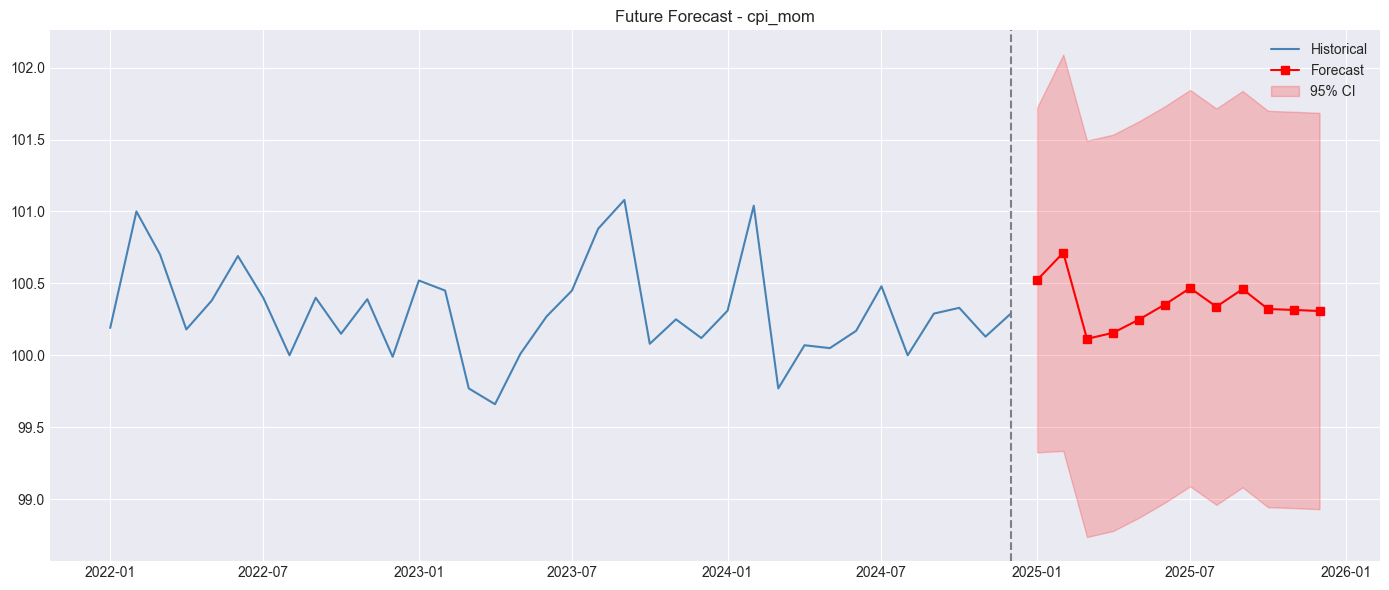

              forecast   lower_95    upper_95
2025-01-01  100.523025  99.325312  101.720738
2025-02-01  100.713161  99.335699  102.090622
2025-03-01  100.114508  98.737047  101.491970
2025-04-01  100.156569  98.779108  101.534030
2025-05-01  100.247122  98.869661  101.624583
2025-06-01  100.352809  98.975348  101.730271
2025-07-01  100.466894  99.089433  101.844356
2025-08-01  100.338028  98.960567  101.715490
2025-09-01  100.459991  99.082530  101.837453
2025-10-01  100.321804  98.944343  101.699265
2025-11-01  100.315386  98.937925  101.692847
2025-12-01  100.307805  98.930344  101.685267


In [15]:
performance_good = (best_row["Model_vs_RW"] < 1) or (best_row["R2"] > 0)
residual_ok = ljung["lb_pvalue"].min() > 0.05

print("Mô hình đạt benchmark:", performance_good)
print("Phần dư đạt Ljung-Box:", residual_ok)

future_steps = 12

if performance_good:
    exog_cols = best_row["exog_cols"]
    order = best_row["order"]
    seasonal_order = best_row["seasonal_order"]
    y_full = df_model[target_var]

    if len(exog_cols) == 0:
        exog_full = None
        exog_future = None
    else:
        exog_full = df_model[exog_cols]
        future_index = pd.date_range(start=df_model.index[-1], periods=future_steps + 1, freq="MS")[1:]
        exog_future = pd.DataFrame(index=future_index)
        for col in exog_cols:
            if col == "month":
                exog_future[col] = future_index.month
            elif col == "quarter":
                exog_future[col] = future_index.quarter
            elif col.startswith("shock_"):
                exog_future[col] = 0
            else:
                exog_future[col] = exog_full[col].iloc[-1]

    final_model = SARIMAX(y_full, exog=exog_full, order=order, trend="c", seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
    final_res = final_model.fit(disp=False, maxiter=300)
    future = final_res.get_forecast(steps=future_steps, exog=exog_future)
    future_mean = future.predicted_mean
    future_ci = future.conf_int(alpha=0.05)

    plt.figure(figsize=(14, 6))
    plt.plot(y_full.index[-36:], y_full.iloc[-36:], label="Historical", color="steelblue")
    plt.plot(future_mean.index, future_mean.values, label="Forecast", color="red", marker="s")
    plt.fill_between(future_ci.index, future_ci.iloc[:, 0], future_ci.iloc[:, 1], color="red", alpha=0.2, label="95% CI")
    plt.axvline(y_full.index[-1], color="gray", linestyle="--")
    plt.title(f"Future Forecast - {target_var}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "future_forecast.png"), dpi=150)
    plt.show()

    future_df = pd.DataFrame({"forecast": future_mean, "lower_95": future_ci.iloc[:, 0], "upper_95": future_ci.iloc[:, 1]})
    future_df.to_csv(os.path.join(OUTPUT_DIR, "future_forecast.csv"))
    print(future_df.to_string())
else:
    print("Không vẽ dự báo tương lai vì mô hình chưa vượt benchmark.")

## 15. Tóm tắt

In [16]:
print("Target:", target_var)
print("Best model:", best_key)
print("RMSE:", round(best_row["RMSE"], 6))
print("MAE:", round(best_row["MAE"], 6))
print("R2:", round(best_row["R2"], 4))
print("Model_vs_RW:", round(best_row["Model_vs_RW"], 4))
print("Model_vs_Mean:", round(best_row["Model_vs_Mean"], 4))
print("Output:", OUTPUT_DIR)

Target: cpi_mom
Best model: SARIMA_(0, 0, 1)_(1, 0, 1, 12)
RMSE: 0.482143
MAE: 0.367407
R2: -0.0547
Model_vs_RW: 0.7021
Model_vs_Mean: 0.8979
Output: d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\outputs\step4_sarimax
